### Week 2-3: Dataset Structuring and Validation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [3]:
sold_path = "data/sold_combined.csv"
listing_path = "data/listing_combined.csv"

sold = pd.read_csv(sold_path, low_memory = False)
listing = pd.read_csv(listing_path, low_memory = False)

#low_memory helps read the file without looking at the data types just yet.

In [4]:
#Inspecting the SOLD structure

print("Sold")
print("-----")
print(f"Shape: {sold.shape}")
sold.head()
sold.info()
sold.isnull().sum()



Sold
-----
Shape: (262311, 84)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262311 entries, 0 to 262310
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 249139 non-null  object 
 1   ListAgentAOR                  249216 non-null  object 
 2   Flooring                      168614 non-null  object 
 3   ViewYN                        239628 non-null  object 
 4   WaterfrontYN                  147 non-null     object 
 5   BasementYN                    5203 non-null    object 
 6   PoolPrivateYN                 239565 non-null  object 
 7   OriginalListPrice             261835 non-null  float64
 8   ListingKey                    262311 non-null  int64  
 9   ListAgentEmail                260762 non-null  object 
 10  CloseDate                     262311 non-null  object 
 11  ClosePrice                    262310 non-null  float64
 12  ListAgentFirs

BuyerAgentAOR                   13172
ListAgentAOR                    13095
Flooring                        93697
ViewYN                          22683
WaterfrontYN                   262164
                                ...  
lonfilled                      216236
OriginatingSystemName          261495
OriginatingSystemSubName       261495
BuyerAgencyCompensationType    249250
BuyerAgencyCompensation        249252
Length: 84, dtype: int64

In [5]:
#print(listing.head())
listing.info()
listing.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400993 entries, 0 to 400992
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             400429 non-null  float64
 1   ListingKey                    400993 non-null  int64  
 2   ListAgentEmail                398497 non-null  object 
 3   CloseDate                     120236 non-null  object 
 4   ClosePrice                    105427 non-null  float64
 5   ListAgentFirstName            397806 non-null  object 
 6   ListAgentLastName             400967 non-null  object 
 7   Latitude                      334805 non-null  float64
 8   Longitude                     334805 non-null  float64
 9   UnparsedAddress               400490 non-null  object 
 10  PropertyType                  400993 non-null  object 
 11  LivingArea                    400571 non-null  float64
 12  ListPrice                     400993 non-nul

OriginalListPrice                  564
ListingKey                           0
ListAgentEmail                    2496
CloseDate                       280757
ClosePrice                      295566
                                 ...  
LotSizeSquareFeet                32652
MiddleOrJuniorSchoolDistrict    400993
UnparsedAddress.1                  503
BuyerAgencyCompensationType     321980
BuyerAgencyCompensation         322000
Length: 84, dtype: int64

In [6]:
sold_missing = pd.DataFrame({'missing_count': sold.isnull().sum(), 'missing_percent': (sold.isnull().sum()/len(sold)*100).round(2)}).sort_values('missing_percent', ascending = False)
print(f"""Sold: 
      {sold_missing[sold_missing['missing_percent'] > 90]}
""")

Sold: 
                                    missing_count  missing_percent
AboveGradeFinishedArea               262311           100.00
ElementarySchoolDistrict             262311           100.00
FireplacesTotal                      262311           100.00
TaxYear                              262311           100.00
BusinessType                         262311           100.00
CoveredSpaces                        262311           100.00
MiddleOrJuniorSchoolDistrict         262311           100.00
TaxAnnualAmount                      262311           100.00
WaterfrontYN                         262164            99.94
OriginatingSystemSubName             261495            99.69
OriginatingSystemName                261495            99.69
BelowGradeFinishedArea               260762            99.41
BasementYN                           257108            98.02
BuilderName                          249599            95.15
LotSizeDimensions                    249491            95.11
BuyerAgency

In [7]:
listing_missing = pd.DataFrame({'missing_count': listing.isnull().sum(), 'missing_percent': (listing.isnull().sum()/len(listing)*100).round(2)}).sort_values('missing_percent', ascending = False)
print(f"""Listing:
    {listing_missing[listing_missing['missing_percent']>90]}
""")

Listing:
                                  missing_count  missing_percent
TaxAnnualAmount                      400993           100.00
FireplacesTotal                      400993           100.00
ElementarySchoolDistrict             400993           100.00
BusinessType                         400993           100.00
TaxYear                              400993           100.00
CoveredSpaces                        400993           100.00
MiddleOrJuniorSchoolDistrict         400993           100.00
AboveGradeFinishedArea               400993           100.00
BelowGradeFinishedArea               398791            99.45
CoBuyerAgentFirstName                390604            97.41
BuilderName                          382428            95.37
LotSizeDimensions                    379972            94.76
BuildingAreaTotal                    365424            91.13



In [8]:
sold_missing.to_csv("data/sold_missing_report.csv")
listing_missing.to_csv("data/listing_missing_report.csv")

In [10]:
print("SOLD columns:")
print(sorted(sold.columns.tolist()))

print("\nLISTING columns:")
print(sorted(listing.columns.tolist()))

SOLD columns:
['AboveGradeFinishedArea', 'AssociationFee', 'AssociationFeeFrequency', 'AttachedGarageYN', 'BasementYN', 'BathroomsTotalInteger', 'BedroomsTotal', 'BelowGradeFinishedArea', 'BuilderName', 'BuildingAreaTotal', 'BusinessType', 'BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'BuyerAgentAOR', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerOfficeName', 'City', 'CloseDate', 'ClosePrice', 'CoBuyerAgentFirstName', 'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName', 'ContractStatusChangeDate', 'CountyOrParish', 'CoveredSpaces', 'DaysOnMarket', 'ElementarySchool', 'ElementarySchoolDistrict', 'FireplaceYN', 'FireplacesTotal', 'Flooring', 'GarageSpaces', 'HighSchool', 'HighSchoolDistrict', 'Latitude', 'Levels', 'ListAgentAOR', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentFullName', 'ListAgentLastName', 'ListOfficeName', 'ListPrice', 'ListingContractDate', 'ListingId', 'ListingKey', 'ListingKeyNumeric', 'LivingAre

In [9]:
market_analysis_fields = [
     # prices
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    # features about the property
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 
    'LotSizeAcres', 'LotSizeArea', 'LotSizeSquareFeet', 'YearBuilt',
    'Stories', 'Levels', 'GarageSpaces', 'ParkingTotal',
    'AttachedGarageYN', 'PoolPrivateYN', 'FireplaceYN', 'ViewYN', 'Flooring',
    # dates
    'CloseDate', 'ListingContractDate', 'PurchaseContractDate', 
    'ContractStatusChangeDate',
    # market info
    'DaysOnMarket', 'AssociationFee', 'AssociationFeeFrequency',
    # location (city, latitude, etc)
    'CountyOrParish', 'MLSAreaMajor', 'City', 'PostalCode',
    'Latitude', 'Longitude', 'UnparsedAddress', 'StateOrProvince',
    'SubdivisionName',
    # property type
    'PropertyType', 'PropertySubType', 'NewConstructionYN',
    # agents and offices
    'ListOfficeName', 'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName',
    'BuyerOfficeName', 'BuyerAgentFirstName', 'BuyerAgentLastName',
    'CoListOfficeName', 'CoListAgentFirstName', 'CoListAgentLastName',
]


metadata_fields = [
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    'ListAgentEmail', 'ListAgentAOR', 'BuyerAgentAOR', 'BuyerAgentMlsId',
    'BuyerOfficeAOR', 'MlsStatus',
    # taxes but also mostly empty
    'TaxAnnualAmount', 'TaxYear',
    #most empty
    'FireplacesTotal', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
    'BuildingAreaTotal', 'CoveredSpaces', 'MainLevelBedrooms',
    'WaterfrontYN', 'BasementYN', 'BuilderName',
    'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
    'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict', 'HighSchoolDistrict',
    'LotSizeDimensions', 'StreetNumberNumeric',
    'CoBuyerAgentFirstName', 'BusinessType',
    'latfilled', 'lonfilled',
    'OriginatingSystemName', 'OriginatingSystemSubName',
    'BuyerAgencyCompensationType', 'BuyerAgencyCompensation'
]


In [10]:
sold_dropping_missing_cols = sold_missing[sold_missing['missing_percent'] > 90]

sold_cleaned = sold.drop( columns= sold_dropping_missing_cols, errors = 'ignore')
sold_keep_cols = []
for col in market_analysis_fields:
    if col in sold_cleaned.columns:
        sold_keep_cols.append(col)
sold_cleaned = sold_cleaned[sold_keep_cols].copy()




listing_dropping_missing_cols = listing_missing[listing_missing['missing_percent'] > 90]

listing_cleaned = listing.drop(columns=listing_dropping_missing_cols, errors = 'ignore')
listing_keep_cols = []
for col in market_analysis_fields:
    if col in listing_cleaned.columns:
        listing_keep_cols.append(col)
listing_cleaned = listing_cleaned[listing_keep_cols].copy() 


print(sold_cleaned.shape)
print(listing_cleaned.shape)


(262311, 48)
(400993, 45)


In [11]:
print("SOLD data types:")
print(sold_cleaned.dtypes.to_string())

SOLD data types:
ClosePrice                  float64
ListPrice                   float64
OriginalListPrice           float64
LivingArea                  float64
BedroomsTotal               float64
BathroomsTotalInteger       float64
LotSizeAcres                float64
LotSizeArea                 float64
LotSizeSquareFeet           float64
YearBuilt                   float64
Stories                     float64
Levels                       object
GarageSpaces                float64
ParkingTotal                float64
AttachedGarageYN             object
PoolPrivateYN                object
FireplaceYN                  object
ViewYN                       object
Flooring                     object
CloseDate                    object
ListingContractDate          object
PurchaseContractDate         object
ContractStatusChangeDate     object
DaysOnMarket                  int64
AssociationFee              float64
AssociationFeeFrequency      object
CountyOrParish               object
MLSAreaMajo

In [12]:
print("Listing data types:")
print(listing_cleaned.dtypes.to_string())

Listing data types:
ClosePrice                  float64
ListPrice                   float64
OriginalListPrice           float64
LivingArea                  float64
BedroomsTotal               float64
BathroomsTotalInteger       float64
LotSizeAcres                float64
LotSizeArea                 float64
LotSizeSquareFeet           float64
YearBuilt                   float64
Stories                     float64
Levels                       object
GarageSpaces                float64
ParkingTotal                float64
AttachedGarageYN             object
FireplaceYN                  object
CloseDate                    object
ListingContractDate          object
PurchaseContractDate         object
ContractStatusChangeDate     object
DaysOnMarket                  int64
AssociationFee              float64
AssociationFeeFrequency      object
CountyOrParish               object
MLSAreaMajor                 object
City                         object
PostalCode                   object
Latitude

In [13]:
date_field = ['CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate']

for col in date_field:
    sold_cleaned[col] = pd.to_datetime(sold_cleaned[col], errors = 'coerce')
    listing_cleaned[col] = pd.to_datetime(listing_cleaned[col], errors = 'coerce')


int_field = ['BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'Stories', 'GarageSpaces', 'ParkingTotal']

for col in int_field:
    if col in sold_cleaned.columns:
        sold_cleaned[col] = sold_cleaned[col].round(0).astype('Int64')
    if col in listing_cleaned.columns:
        listing_cleaned[col] = listing_cleaned[col].round(0).astype('Int64')

# should i use Int64 or just int? 
numeric_fields = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
    'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger',
    'DaysOnMarket', 'YearBuilt'
]

#MISING VALUES IN NUMERIC FIELDS
for col in numeric_fields:
    print(f"""Column Name: {col}
        Number of values missing: {sold_cleaned[col].isnull().sum()}
          """)


Column Name: ClosePrice
        Number of values missing: 1
          
Column Name: ListPrice
        Number of values missing: 0
          
Column Name: OriginalListPrice
        Number of values missing: 476
          
Column Name: LivingArea
        Number of values missing: 157
          
Column Name: LotSizeAcres
        Number of values missing: 20532
          
Column Name: BedroomsTotal
        Number of values missing: 7
          
Column Name: BathroomsTotalInteger
        Number of values missing: 46
          
Column Name: DaysOnMarket
        Number of values missing: 0
          
Column Name: YearBuilt
        Number of values missing: 249
          


In [14]:
sold_cleaned.to_csv("data/sold_cleaned.csv", index=False)
listing_cleaned.to_csv("data/listing_cleaned.csv", index=False)


In [16]:
### Numeric Distribution + Percentiles
numeric_fields = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
    'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger',
    'DaysOnMarket', 'YearBuilt'
]

print(sold_cleaned[numeric_fields].describe(percentiles=[.25, .50, .75, .95]))
# median is 50th percentile! 
print(listing_cleaned[numeric_fields].describe(percentiles=[.25, .50, .75, .95]))

         ClosePrice     ListPrice  OriginalListPrice     LivingArea  \
count  2.623100e+05  2.623110e+05       2.618350e+05  262154.000000   
mean   1.199952e+06  1.144734e+06       1.246998e+06    1862.574015   
std    6.423276e+06  1.364839e+06       7.648187e+06    1000.558543   
min    0.000000e+00  5.250000e+02       0.000000e+00       0.000000   
25%    5.760000e+05  5.790000e+05       5.890000e+05    1248.000000   
50%    8.250000e+05  8.200000e+05       8.299990e+05    1642.000000   
75%    1.300000e+06  1.295000e+06       1.299000e+06    2216.000000   
95%    2.850000e+06  2.874500e+06       2.925000e+06    3567.000000   
max    9.000000e+08  1.375000e+08       1.390000e+09   84500.000000   

       LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket  \
count  2.417790e+05       262304.0               262265.0  262311.000000   
mean   6.247818e+01       3.203741               2.534116      37.251682   
std    1.226422e+04       1.067333               1.128548    

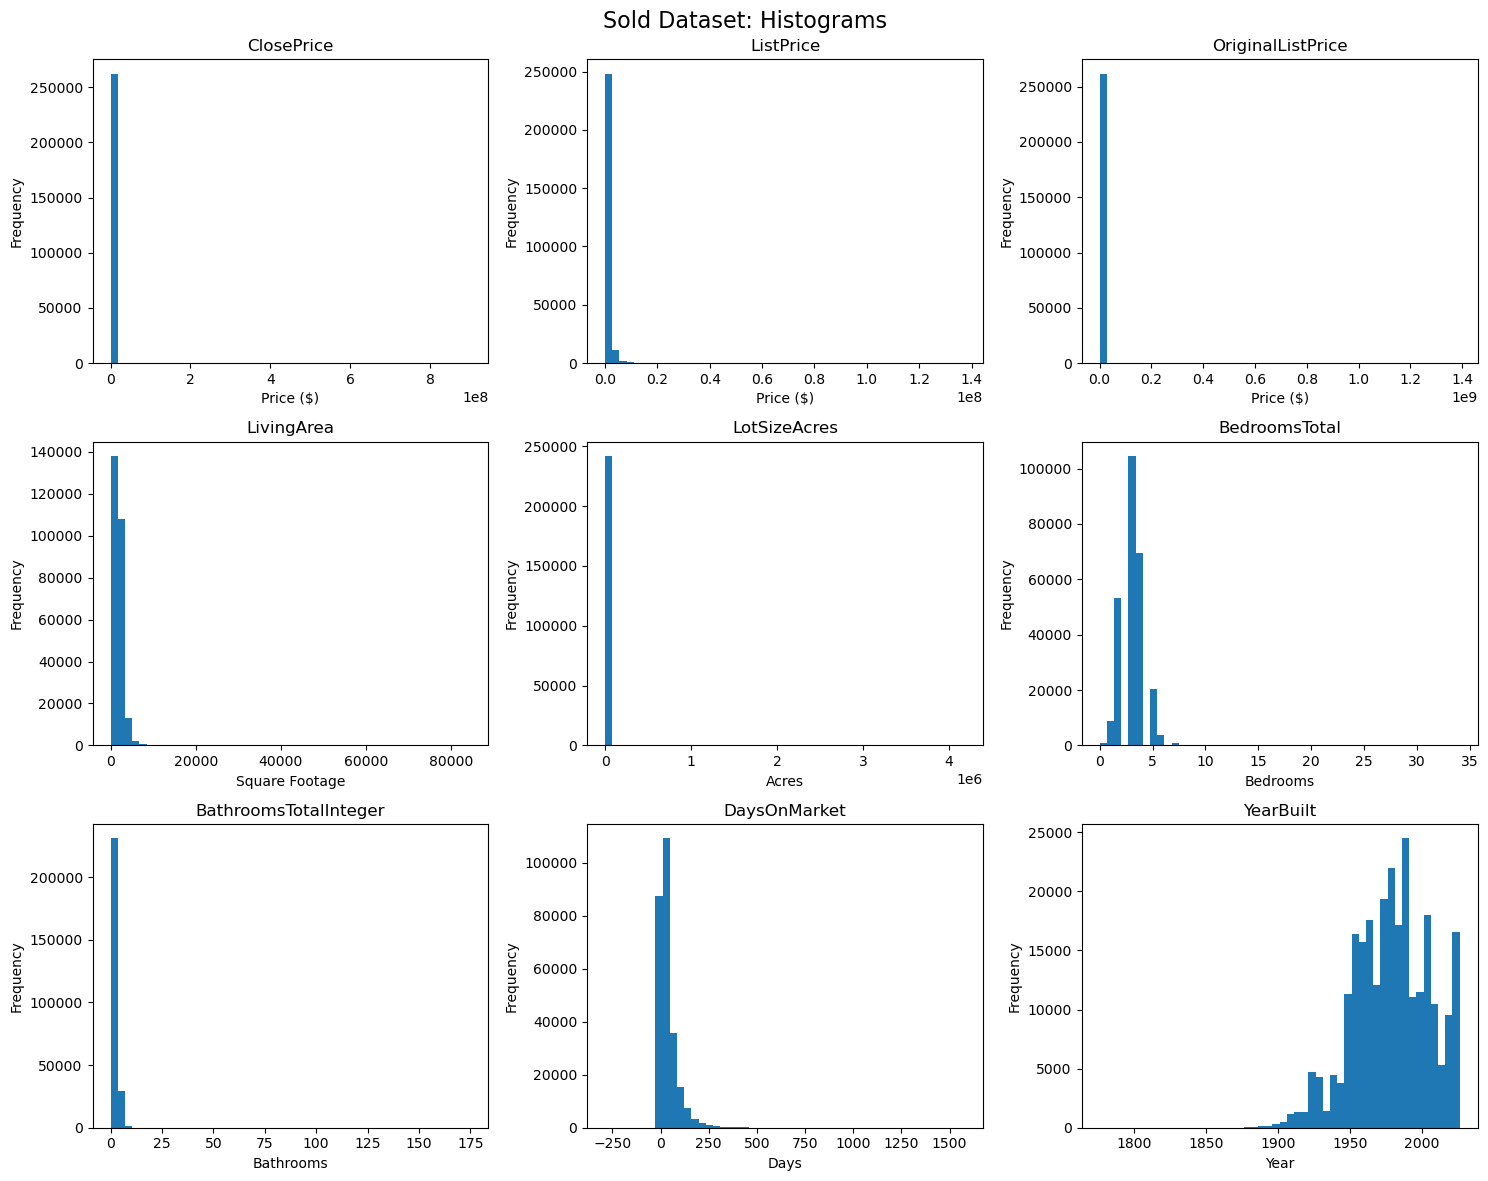

In [17]:
#Histograms 

#need subplots for the 9 numeric fields
fig,axes = plt.subplots(3,3, figsize = (15,12))
fig.suptitle('Sold Dataset: Histograms', fontsize=16)

x_labels = {
    'ClosePrice': 'Price ($)',
    'ListPrice': 'Price ($)',
    'OriginalListPrice': 'Price ($)',
    'LivingArea': 'Square Footage',
    'LotSizeAcres': 'Acres',
    'BedroomsTotal': 'Bedrooms',
    'BathroomsTotalInteger': 'Bathrooms',
    'DaysOnMarket': 'Days',
    'YearBuilt': 'Year'
}

for i, col in enumerate(numeric_fields):

    #this goes well with the loop when trying to create plot in a 3x3 grid
    ax = axes[i // 3, i % 3]
    #need to remove missing values
    sold_cleaned[col].dropna().plot(kind='hist', bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(x_labels[col])


plt.tight_layout()
plt.show()

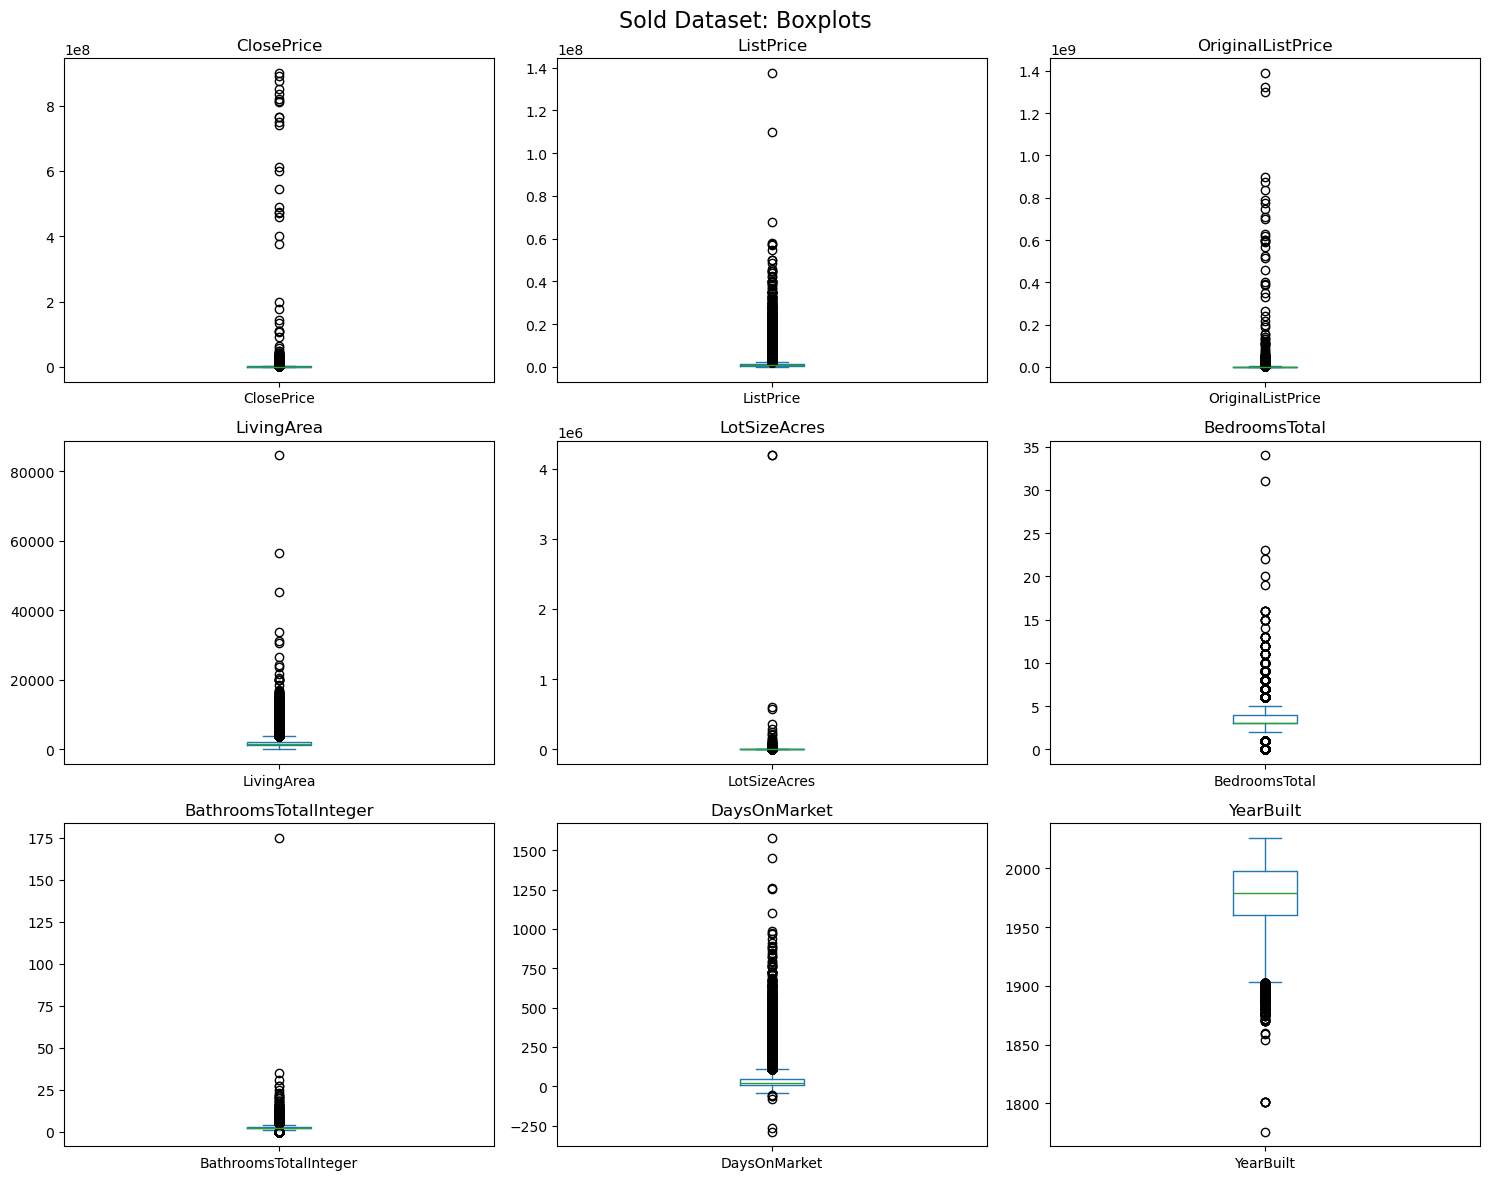

In [18]:
#boxplots + outliers
fig,axes = plt.subplots(3,3, figsize = (15,12))
fig.suptitle('Sold Dataset: Boxplots', fontsize=16)


for i, col in enumerate(numeric_fields):

    #this goes well with the loop when trying to create plot in a 3x3 grid
    ax = axes[i // 3, i % 3]
    #need to remove missing values
    sold_cleaned[col].dropna().plot(kind='box', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [19]:
print(f"Days on Market Distribution (Listing): \n{listing_cleaned['DaysOnMarket'].describe(percentiles=[.25, .50, .75, .95])}")
print(f"\nDays on Market Distribution (Sold): \n{sold_cleaned['DaysOnMarket'].describe(percentiles=[.25, .50, .75, .95])}")


Days on Market Distribution (Listing): 
count    400993.000000
mean         18.785206
std          26.001438
min         -58.000000
25%           5.000000
50%          10.000000
75%          22.000000
95%          70.000000
max         677.000000
Name: DaysOnMarket, dtype: float64

Days on Market Distribution (Sold): 
count    262311.000000
mean         37.251682
std          49.025913
min        -288.000000
25%           8.000000
50%          19.000000
75%          49.000000
95%         129.000000
max        1580.000000
Name: DaysOnMarket, dtype: float64


In [20]:
above_price = (sold_cleaned['ClosePrice'] > sold_cleaned['ListPrice']).sum()
below_price = (sold_cleaned['ClosePrice'] < sold_cleaned['ListPrice']).sum()
equal_price = (sold_cleaned['ClosePrice'] == sold_cleaned['ListPrice']).sum()
total = len(sold_cleaned)

print(f"Above: {above_price:,} ({above_price/total*100:.1f}%)")
print(f"Below: {below_price:,} ({below_price/total*100:.1f}%)")
print(f"At listing price: {equal_price:,} ({equal_price/total*100:.1f}%)")


Above: 103,554 (39.5%)
Below: 113,121 (43.1%)
At listing price: 45,635 (17.4%)


In [21]:
listing_after_close = (sold_cleaned['ListingContractDate'] > sold_cleaned['CloseDate']).sum()
purchase_after_close = (sold_cleaned['PurchaseContractDate'] > sold_cleaned['CloseDate']).sum()
listing_after_purchase = (sold_cleaned['ListingContractDate'] > sold_cleaned['PurchaseContractDate']).sum()


print(f"Listing date after close date: {listing_after_close:,}")
print(f"Purchase date after close date: {purchase_after_close:,}")
print(f"Listing date after purchase date: {listing_after_purchase:,}")


Listing date after close date: 41
Purchase date after close date: 154
Listing date after purchase date: 177


In [22]:
county_count = sold_cleaned.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending = False)
print(f"County by Median Close Price:\n {county_count}")

County by Median Close Price:
 CountyOrParish
Other County       187632500.0
Del Norte            2485000.0
San Mateo            1700000.0
Santa Clara          1600000.0
Marin                1255000.0
                      ...     
Lake                  310000.0
Sierra                255000.0
Foreign Country       247500.0
Modoc                 225000.0
Lassen                131250.0
Name: ClosePrice, Length: 63, dtype: float64


In [24]:
print(sold_cleaned.shape)
print(listing_cleaned.shape)

(262311, 48)
(400993, 45)
